### Univariate Analysis
Analyzing **one variable at a time** to understand:
- Distribution
- Central tendency
- Spread
- Outliers
- Skewness

### Why Univariate Analysis is CRITICAL for ML
| Observation      | ML Impact                    |
| ---------------- | ---------------------------- |
| Skewed data      | Linear models perform poorly |
| Extreme outliers | KNN, Linear, SVM break       |
| Zero variance    | Feature useless              |
| Long tails       | Need log / power transform   |

In [1]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(42)

data = pd.DataFrame({
    "age": np.random.normal(loc=35, scale=10, size=1000).astype(int)
})
data

,age
0,39
1,33
2,41
3,50
4,32
...,...
995,32
996,52
997,41
998,29


In [4]:
data["age"].describe()

count    1000.000000
mean       34.674000
std         9.797741
min         2.000000
25%        28.000000
50%        35.000000
75%        41.000000
max        73.000000
Name: age, dtype: float64

#### What to look at:
- **mean vs median** -> skewness
- **std** -> spread
- **min / max** -> potential outliers

#### Thumb Rule:
- If `mean ≠ median` -> skewed data
-  If `max >> 75%` -> possible outliers

### Distribution Analysis
#### Histogram

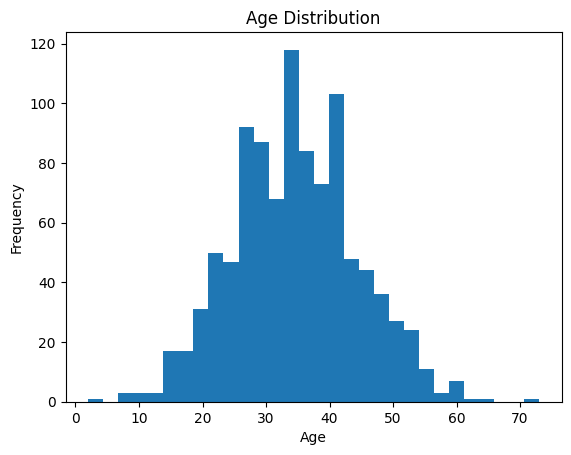

In [6]:
import matplotlib.pyplot as plt

plt.hist(data["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

#### Kernel Density Estimate (Smooth Distribution)

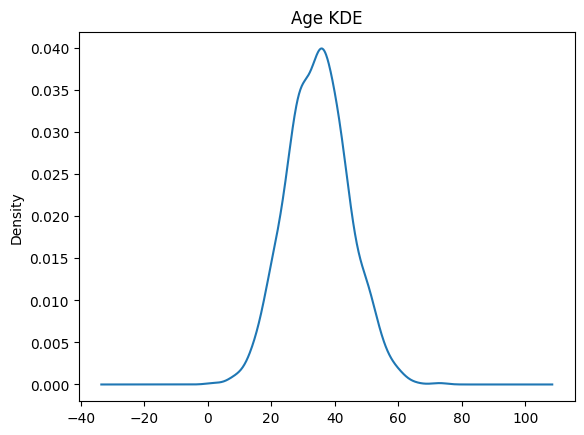

In [7]:
data["age"].plot(kind="kde", title="Age KDE")
plt.show()

**ML Insight**
- Bell-shaped -> good for linear models
- Right-skewed -> log / power transform
- Multi-peak -> mixed population

### Boxplot (Outlier Detector)

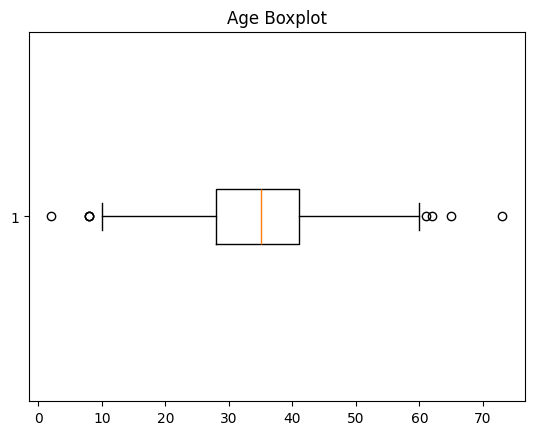

In [9]:
plt.boxplot(data["age"], vert=False)
plt.title("Age Boxplot")
plt.show()

**What boxplot tells instantly:**
- Median position
- Spread (IQR)
- Outliers (dot beyond whiskers)

### Skewness & Kurtosis

In [11]:
data["age"].skew(), data["age"].kurt()

(np.float64(0.11059849403246863), np.float64(0.06371356527085137))

**Interpretation:**
| Metric        | Meaning                |
| ------------- | ---------------------- |
| Skewness > 0  | Right-skewed           |
| Skewness < 0  | Left-skewed            |
| High Kurtosis | Heavy tails (outliers) |


### Zero / Near-Zero Variance Check

In [12]:
data["age"].var()

np.float64(95.99571971971972)

If variance ≈ 0:
- Feature add no **predictive power**
- Should be dropped before ML

### Univariate Analysis for Categorical Features

In [13]:
data_cat = pd.DataFrame({
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore"], size=1000)
})

data_cat["city"].value_counts(normalize=True)

city
Delhi        0.346
Mumbai       0.339
Bangalore    0.315
Name: proportion, dtype: float64

ML insight:
- Highly dominant category -> bias risk
- Rare categories -> encoding problems

| Observation   | Action Later           |
| ------------- | ---------------------- |
| Right skew    | Log / Power transform  |
| Outliers      | Capping / RobustScaler |
| High variance | Scaling needed         |
| Low variance  | Drop feature           |